In [ ]:
!pip install pandas numpy scikit-learn nltk xgboost tensorflow

import pandas as pd
import numpy as np
import nltk

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

import matplotlib.pyplot as plt
import seaborn as sns

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
df = pd.read_csv("WELFake_Dataset.csv", engine='python', on_bad_lines='skip', encoding='latin1')

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (8369, 4)


,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMAâS ATTORNEY GENERAL SAYS ...,"Now, most of the demonstrators gathered last ...",1
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


In [ ]:
df['label'] = df['label'].replace({
    'FAKE': 0, 'REAL': 1,
    'Fake': 0, 'Real': 1
})

df['label'] = pd.to_numeric(df['label'], errors='coerce')
df = df.dropna(subset=['label'])
df['label'] = df['label'].astype(int)

df['title'] = df['title'].fillna('')
df['text'] = df['text'].fillna('')

df['content'] = df['title'] + " " + df['text']

df = df.sample(n=min(20000, len(df)), random_state=42)

print(df['label'].value_counts())

label
1    4363
0    3921
Name: count, dtype: int64


In [ ]:
X = df['content']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_siz
    2, random_state=42
)

In [ ]:
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [ ]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_vec, y_train)

y_pred_lr = lr.predict(X_test_vec)
lr_acc = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression:", lr_acc)

Logistic Regression: 0.9124924562462281


In [ ]:
nb = MultinomialNB()
nb.fit(X_train_vec, y_train)

y_pred_nb = nb.predict(X_test_vec)
nb_acc = accuracy_score(y_test, y_pred_nb)

print("Naive Bayes:", nb_acc)

Naive Bayes: 0.8442969221484611


In [ ]:
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train_vec, y_train)

y_pred_rf = rf.predict(X_test_vec)
rf_acc = accuracy_score(y_test, y_pred_rf)

print("Random Forest:", rf_acc)

Random Forest: 0.9149064574532287


In [ ]:
xgb = XGBClassifier(eval_metric='logloss')
xgb.fit(X_train_vec, y_train)

y_pred_xgb = xgb.predict(X_test_vec)
xgb_acc = accuracy_score(y_test, y_pred_xgb)

print("XGBoost:", xgb_acc)

XGBoost: 0.9324079662039831


In [ ]:
results = {
    "Logistic Regression": lr_acc,
    "Naive Bayes": nb_acc,
    "Random Forest": rf_acc,
    "XGBoost": xgb_acc,
}

for model, score in results.items():
    print(model, ":", round(score, 4))

Logistic Regression : 0.9125
Naive Bayes : 0.8443
Random Forest : 0.9149
XGBoost : 0.9324


In [ ]:
best_model = max(results, key=results.get)
print("Best Model:", best_model)

Best Model: XGBoost


In [ ]:
preds = {
    "Logistic Regression": y_pred_lr,
    "Naive Bayes": y_pred_nb,
    "Random Forest": y_pred_rf,
    "XGBoost": y_pred_xgb
}


Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.91      0.93       802
           1       0.92      0.96      0.94       855

    accuracy                           0.93      1657
   macro avg       0.93      0.93      0.93      1657
weighted avg       0.93      0.93      0.93      1657



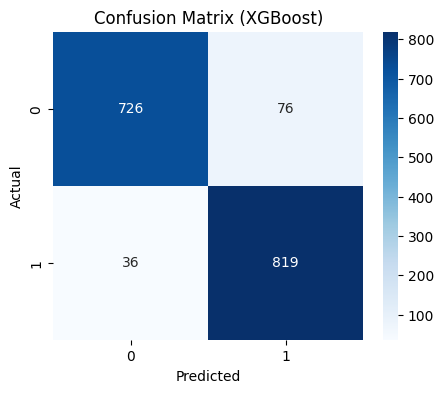

In [ ]:
print("\nClassification Report:")
print(classification_report(y_test, preds[best_model]))

cm = confusion_matrix(y_test, preds[best_model])

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f"Confusion Matrix ({best_model})")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

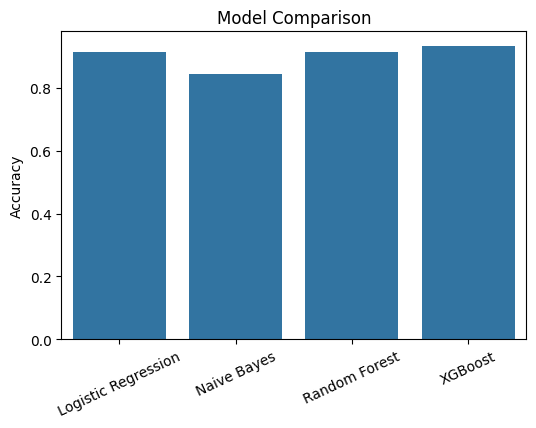

In [ ]:
plt.figure(figsize=(6,4))
sns.barplot(x=list(results.keys()), y=list(results.values()))
plt.xticks(rotation=25)
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.show()